# 02. 저변동성 포트폴리오 위험조정 수익 우위 검증

S&P500 유니버스에서 변동성 기준 분위 포트폴리오를 구성하고  
저변동성(Q1)이 고변동성(Q5) 대비 위험조정 수익이 높은지 검증한다.

## 분석 섹션
| 섹션 | 구간 | 목적 |
|---|---|---|
| 1 | 2010~2024 | 메인 분석 (99_baseline 예측 구간) + Q1-Q5 스프레드 |
| 2 | 2016~2024 | 강세장(2010~2015) 제외 구간 |
| 3 | 2005~2024 | 금융위기(GFC) 포함 전체 기간 |
| 4 | 전체 | 변동성-시가총액 관계 (상관관계 검정) |
| 참고 | 2005~2009 | Pre-sample — BL Q 추정 근거 |

## 방법론
- **포트폴리오 정렬**: 매월 말 vol_252d 기준 5분위 정렬 → 동일가중 수익률
- **Look-ahead bias 방지**: 당월 말 변동성으로 분류 → 다음 달 수익률 측정
- **생존편향 완화**: sp500_membership 기반 해당 월 편입 종목만 포함

## 한계
- S&P500 자체가 생존 편향 내포 (부실기업 편출 후 데이터 종료)
- M&A 프리미엄으로 편출된 고변동성 종목 미반영 → Q5 과소평가 가능성

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import io
import re
import zipfile
import requests
import platform
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR  = Path.cwd()
DATA_DIR  = BASE_DIR / 'data'
OUT_DIR   = BASE_DIR / 'outputs' / '02_anomaly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PANEL_PATH = DATA_DIR / 'monthly_panel.csv'
assert PANEL_PATH.exists(), '01_DataCollection.ipynb 먼저 실행하세요'

monthly_df = pd.read_csv(PANEL_PATH, parse_dates=['date'])
monthly_df = monthly_df.set_index(['date', 'ticker'])

print(f'패널 로드: {monthly_df.shape}')
print(f'기간: {monthly_df.index.get_level_values("date").min().date()} ~ {monthly_df.index.get_level_values("date").max().date()}')
print(f'종목 수: {monthly_df.index.get_level_values("ticker").nunique()}')

패널 로드: (97944, 11)
기간: 2005-01-31 ~ 2024-12-31
종목 수: 600


=== 포트폴리오 구성 기준 검증: 해당 월 S&P500 편입 종목만 포함 ===

월별 종목 수 요약:
  평균: 408개  |  최소: 332개  |  최대: 492개

[연도별 평균 종목 수]
  2005: 333개
  2006: 339개
  2007: 343개
  2008: 350개
  2009: 355개
  2010: 357개
  2011: 363개
  2012: 375개
  2013: 388개
  2014: 395개
  2015: 406개
  2016: 427개
  2017: 441개
  2018: 446개
  2019: 451개
  2020: 462개
  2021: 469개
  2022: 477개
  2023: 486개
  2024: 489개

[샘플 월 편입 종목 예시]
  2005-01-31: 332종목  → 예시: ['A', 'AA', 'AAPL', 'ABT', 'ADBE']
  2010-01-31: 355종목  → 예시: ['A', 'AA', 'AAPL', 'ABT', 'ADBE']
  2015-01-31: 398종목  → 예시: ['A', 'AA', 'AAPL', 'ABBV', 'ABT']
  2020-01-31: 458종목  → 예시: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV']
  2024-12-31: 492종목  → 예시: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT']


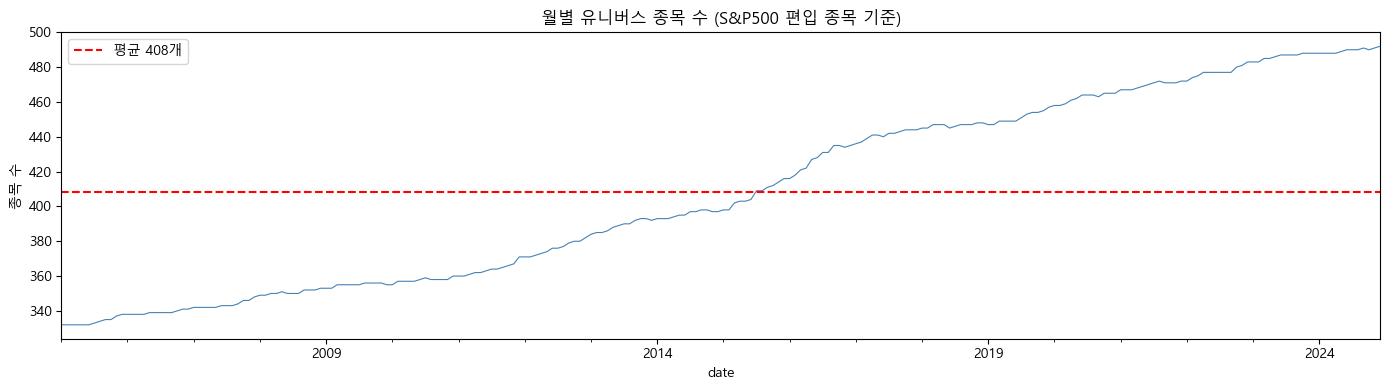

In [41]:
# ── 멤버십 필터링 검증: 실제로 당시 S&P500 편입 종목만 포함되는지 ──
print("=== 포트폴리오 구성 기준 검증: 해당 월 S&P500 편입 종목만 포함 ===\n")

monthly_counts = monthly_df.groupby(level='date').size()
print(f"월별 종목 수 요약:")
print(f"  평균: {monthly_counts.mean():.0f}개  |  최소: {monthly_counts.min()}개  |  최대: {monthly_counts.max()}개\n")

print("[연도별 평균 종목 수]")
yearly = monthly_counts.groupby(monthly_counts.index.year).mean().astype(int)
for yr, cnt in yearly.items():
    print(f"  {yr}: {cnt}개")

print("\n[샘플 월 편입 종목 예시]")
sample_dates = monthly_counts.index[[0, 60, 120, 180, -1]]
for d in sample_dates:
    tickers = monthly_df.loc[d].index.tolist()
    print(f"  {d.date()}: {len(tickers)}종목  → 예시: {tickers[:5]}")

# 시각화
fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(ax=ax, color='steelblue', linewidth=0.8)
ax.axhline(monthly_counts.mean(), color='red', linestyle='--',
           label=f'평균 {monthly_counts.mean():.0f}개')
ax.set_title('월별 유니버스 종목 수 (S&P500 편입 종목 기준)')
ax.set_ylabel('종목 수')
ax.legend()
plt.tight_layout()
plt.show()

=== 기술통계 ===
           ret_1m   beta_252d    vol_252d
count  97910.0000  97352.0000  97352.0000
mean       0.0107      1.0221      0.3093
std        0.0915      0.4000      0.1734
min       -0.8435     -1.6255      0.0905
1%        -0.2300      0.1726      0.1293
5%        -0.1256      0.4190      0.1525
25%       -0.0369      0.7657      0.2054
50%        0.0112      0.9963      0.2645
75%        0.0570      1.2483      0.3590
95%        0.1449      1.7096      0.5996
99%        0.2571      2.1441      0.9788
max        2.4498      3.9243      2.8059

=== 극단값 확인 ===



[ret_1m]
  min=-0.8435  max=2.4498
  1%=-0.2300  99%=0.2571
  1~99% 밖 관측 수: 1960개 (2.0%)

[beta_252d]
  min=-1.6255  max=3.9243
  1%=0.1726  99%=2.1441
  1~99% 밖 관측 수: 1948개 (2.0%)

[vol_252d]
  min=0.0905  max=2.8059
  1%=0.1293  99%=0.9788
  1~99% 밖 관측 수: 1948개 (2.0%)

=== ret_1m 최대값 상위 10개 ===
date        ticker
2009-08-31  AIG       2.449770
2010-02-28  GR        2.333333
2020-04-30  APA       2.138438
2009-01-31  GR        2.000000
            EP        1.857143
2008-08-31  MBI       1.735245
2009-05-31  GNW       1.508475
2009-03-31  AIG       1.380952
2009-04-30  F         1.273765
2010-01-31  EP        1.074468
Name: ret_1m, dtype: float64

=== ret_1m 최솟값 하위 10개 ===
date        ticker
2008-09-30  AIG      -0.843476
2020-03-31  APA      -0.832263
2008-10-31  HIG      -0.748231
2008-11-30  THC      -0.723744
2009-01-31  FITB     -0.710654
2020-03-31  NCLH     -0.705851
2008-11-30  GNW      -0.700413
2020-03-31  OKE      -0.673111
2009-02-28  AIG      -0.671875
2008-12-31  GR    

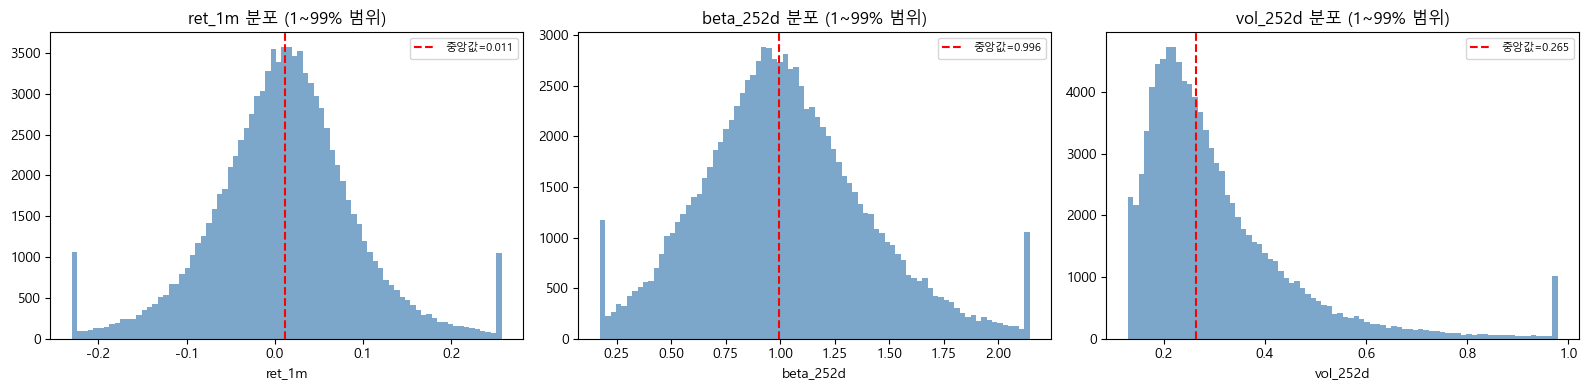

In [42]:
# ── 주요 변수 분포 확인 (포트폴리오 정렬 전) ─────────────────
cols = ['ret_1m', 'beta_252d', 'vol_252d']

print("=== 기술통계 ===")
print(monthly_df[cols].describe(percentiles=[0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).round(4))

print("\n=== 극단값 확인 ===")
for col in cols:
    s = monthly_df[col].dropna()
    print(f"\n[{col}]")
    print(f"  min={s.min():.4f}  max={s.max():.4f}")
    print(f"  1%={s.quantile(0.01):.4f}  99%={s.quantile(0.99):.4f}")
    n_extreme = ((s < s.quantile(0.01)) | (s > s.quantile(0.99))).sum()
    print(f"  1~99% 밖 관측 수: {n_extreme}개 ({n_extreme/len(s):.1%})")

# ── 극단값 원인 확인: ret_1m 상위/하위 10개 ───────────────
print("\n=== ret_1m 최대값 상위 10개 ===")
print(monthly_df['ret_1m'].nlargest(10))

print("\n=== ret_1m 최솟값 하위 10개 ===")
print(monthly_df['ret_1m'].nsmallest(10))

# ── 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, cols):
    s = monthly_df[col].dropna()
    p1, p99 = s.quantile(0.01), s.quantile(0.99)
    ax.hist(s.clip(p1, p99), bins=80, color='steelblue', alpha=0.7)
    ax.set_title(f'{col} 분포 (1~99% 범위)')
    ax.set_xlabel(col)
    ax.axvline(s.median(), color='red', linestyle='--', label=f'중앙값={s.median():.3f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 1. 포트폴리오 정렬 (Portfolio Sort)

## 방법
매월 말 시점에 `beta_252d` 기준으로 5분위 정렬:
- **Q1**: 저베타 (저위험)
- **Q5**: 고베타 (고위험)

각 분위에서 동일가중(Equal-Weight) 포트폴리오를 구성하고 다음 달 수익률(`ret_1m`)을 측정한다.

**Look-ahead bias 방지**: 당월 말 beta로 분류 → 다음 달 수익률 측정 (이미 `ret_1m`에 반영)

In [43]:
def portfolio_sort(df, sort_col, ret_col='ret_1m', n_quantiles=5):
    """
    매월 sort_col 기준으로 n_quantiles 분위 포트폴리오 구성.
    각 분위의 동일가중 수익률 반환.
    """
    results = []
    for date, group in df.groupby(level='date'):
        valid = group[[sort_col, ret_col]].dropna()
        if len(valid) < n_quantiles * 5:  # 분위당 최소 5종목
            continue
        try:
            labels = list(range(1, n_quantiles + 1))
            valid['quintile'] = pd.qcut(valid[sort_col], n_quantiles,
                                        labels=labels, duplicates='drop')
            port_ret = valid.groupby('quintile')[ret_col].mean()
            port_ret.name = date
            results.append(port_ret)
        except Exception as e:
            print(f"  [{date.date()}] 스킵: {e}")
            continue
    return pd.DataFrame(results)


# 베타 기준 포트폴리오
beta_ports = portfolio_sort(monthly_df, 'beta_252d')
# 변동성 기준 포트폴리오
vol_ports  = portfolio_sort(monthly_df, 'vol_252d')

# 무위험수익률 (월별)
rf_monthly = monthly_df['rf_1m'].groupby(level='date').first()

print(f'베타 포트폴리오: {beta_ports.shape[0]}개월 × {beta_ports.shape[1]}분위')
print(f'변동성 포트폴리오: {vol_ports.shape[0]}개월 × {vol_ports.shape[1]}분위')

베타 포트폴리오: 240개월 × 5분위
변동성 포트폴리오: 240개월 × 5분위


In [44]:
# duplicates로 제거되는 분위 수가 있는지 확인
print(beta_ports.isna().sum())

quintile
1    0
2    0
3    0
4    0
5    0
dtype: int64


In [45]:
# ── 전역 변수 및 함수 정의 ────────────────────────────────────
ANN     = np.sqrt(12)
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
labels  = ['Q1 (저위험)', 'Q2', 'Q3', 'Q4', 'Q5 (고위험)']
spy_monthly = monthly_df['spy_ret'].groupby(level='date').first()

def performance_summary(port_df, rf_series, label='베타'):
    rf_aligned = rf_series.reindex(port_df.index)
    rows = []
    for q in port_df.columns:
        r      = port_df[q].dropna()
        rf     = rf_aligned.reindex(r.index)
        excess = r - rf
        rows.append({
            f'{label} 분위': f'Q{q}',
            '연환산 수익률': f'{r.mean()*12:.2%}',
            '연환산 변동성': f'{r.std()*ANN:.2%}',
            'Sharpe Ratio':  f'{excess.mean()/excess.std()*ANN:.3f}',
            '누적 수익률':    f'{(1+r).prod()-1:.2%}',
        })
    return pd.DataFrame(rows).set_index(f'{label} 분위')

print('전역 변수 및 함수 정의 완료')
print(f'  spy_monthly: {spy_monthly.shape[0]}개월 / colors, labels, ANN, performance_summary')

전역 변수 및 함수 정의 완료
  spy_monthly: 240개월 / colors, labels, ANN, performance_summary


=== [2010~2024] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
베타 분위                                      
Q1     12.25%  11.01%        1.003  469.54%
Q2     13.98%  13.45%        0.949  604.12%
Q3     14.27%  16.39%        0.799  588.86%
Q4     14.98%  19.46%        0.709  604.84%
Q5     14.76%  26.17%        0.519  438.12%

=== [2010~2024] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
변동성 분위                                      
Q1      14.69%  11.25%        1.199  714.77%
Q2      13.86%  13.66%        0.927  589.02%
Q3      13.82%  16.02%        0.789  549.62%
Q4      13.47%  19.09%        0.644  469.57%
Q5      14.39%  25.53%        0.517  419.66%


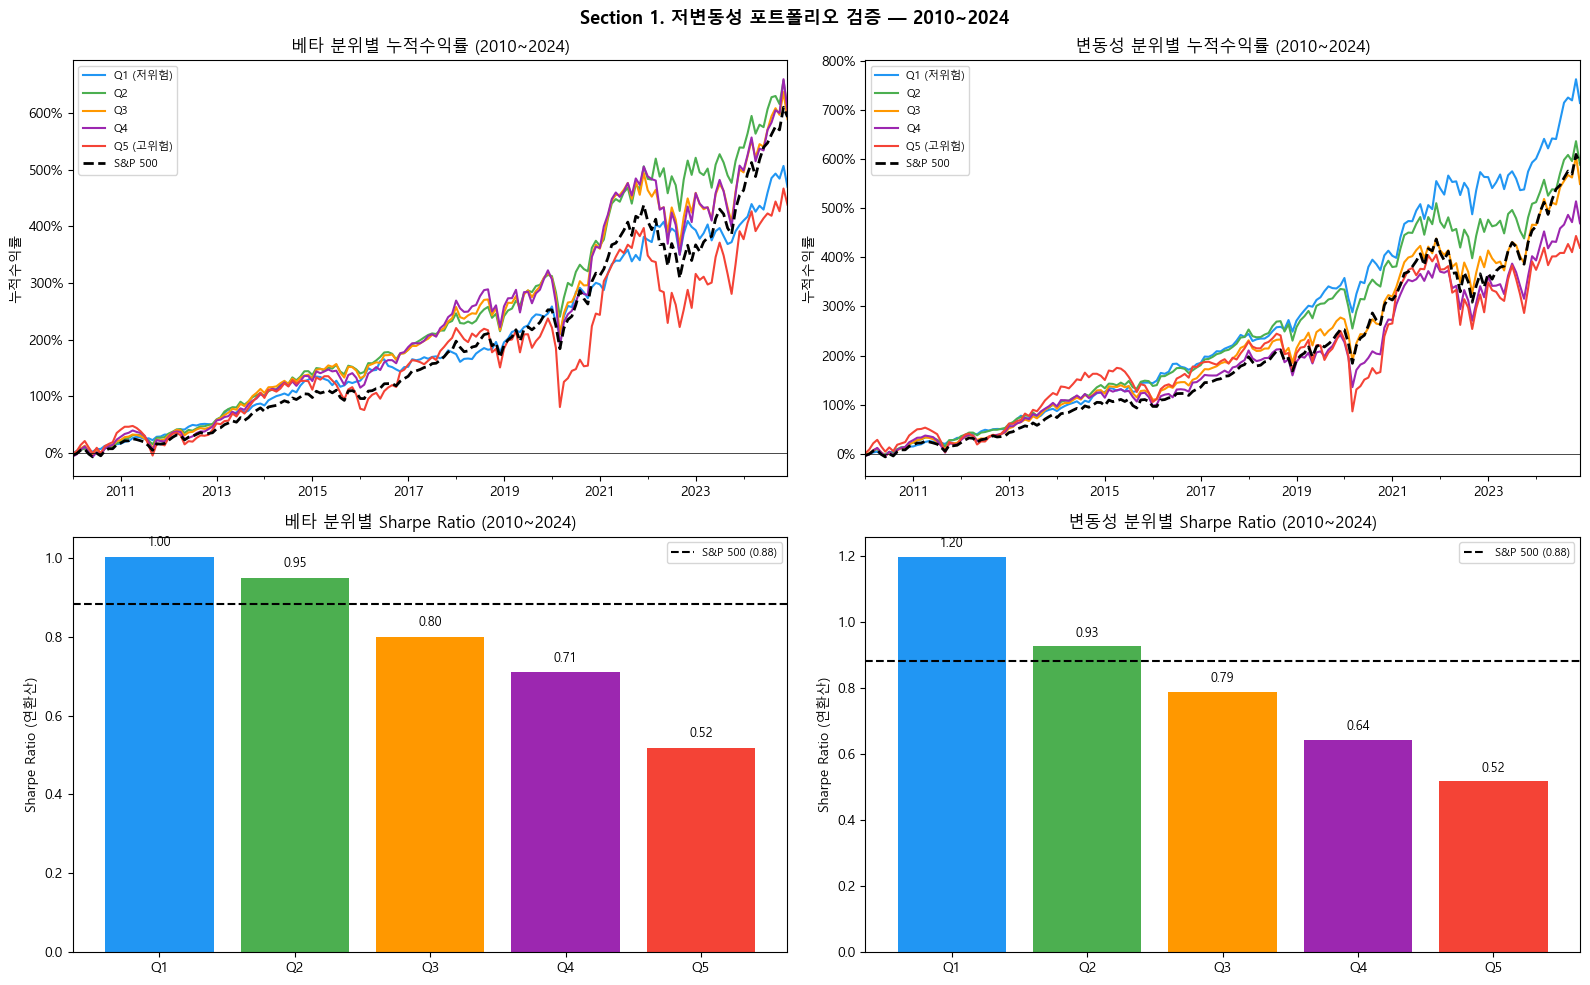


[Q1-Q5 롱숏 스프레드 — 변동성 기준, 2010~2024]
  월평균 스프레드 : 0.0003  (0.30% 연환산)
  스프레드 변동성 : 21.07% (연환산)
  Sharpe          : -0.041
  누적 수익률     : -24.82%
  t-통계량        : 0.055  p-value: 0.9559  → 비유의 ✗


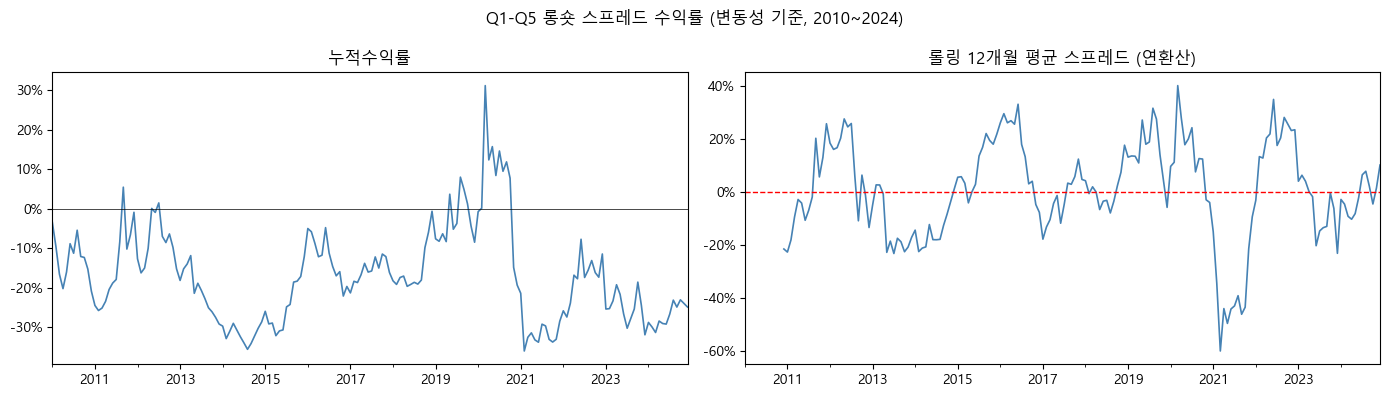

In [46]:
# ── Section 1. 2010~2024 (메인 분석 구간) ───────────────────────
START_BT = '2010-01-01'
END_BT   = '2024-12-31'

df_bt         = monthly_df[
    (monthly_df.index.get_level_values('date') >= START_BT) &
    (monthly_df.index.get_level_values('date') <= END_BT)
]
beta_ports_bt = portfolio_sort(df_bt, 'beta_252d')
vol_ports_bt  = portfolio_sort(df_bt, 'vol_252d')
rf_bt         = rf_monthly[(rf_monthly.index >= START_BT) & (rf_monthly.index <= END_BT)]

print('=== [2010~2024] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports_bt, rf_bt, '베타'))
print('\n=== [2010~2024] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports_bt, rf_bt, '변동성'))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 1. 저변동성 포트폴리오 검증 — 2010~2024', fontsize=13, fontweight='bold')

rf_b_bt  = rf_bt.reindex(beta_ports_bt.index)
rf_v_bt2 = rf_bt.reindex(vol_ports_bt.index)
spy_bt   = spy_monthly[(spy_monthly.index >= START_BT) & (spy_monthly.index <= END_BT)]
spy_cum_bt = (1 + spy_bt).cumprod() - 1

for ax, ports, title in [
    (axes[0, 0], beta_ports_bt, '베타 분위별 누적수익률 (2010~2024)'),
    (axes[0, 1], vol_ports_bt,  '변동성 분위별 누적수익률 (2010~2024)'),
]:
    for i, q in enumerate(ports.columns):
        (1 + ports[q].dropna()).cumprod().sub(1).plot(ax=ax, label=labels[i], color=colors[i])
    spy_cum_bt.reindex(ports.index).plot(ax=ax, label='S&P 500',
                                          color='black', linestyle='--', linewidth=2)
    ax.set_title(title)
    ax.set_ylabel('누적수익률')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

for ax, ports, rf_a, title in [
    (axes[1, 0], beta_ports_bt, rf_b_bt,  '베타 분위별 Sharpe Ratio (2010~2024)'),
    (axes[1, 1], vol_ports_bt,  rf_v_bt2, '변동성 분위별 Sharpe Ratio (2010~2024)'),
]:
    sr_vals = [(ports[q] - rf_a).mean() / (ports[q] - rf_a).std() * ANN
               for q in ports.columns]
    spy_sr  = (spy_bt.reindex(ports.index) - rf_a).mean() / \
              (spy_bt.reindex(ports.index) - rf_a).std() * ANN
    bars = ax.bar([f'Q{q}' for q in ports.columns], sr_vals, color=colors)
    ax.axhline(spy_sr, color='black', linestyle='--', linewidth=1.5,
               label=f'S&P 500 ({spy_sr:.2f})')
    ax.set_title(title)
    ax.set_ylabel('Sharpe Ratio (연환산)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort_2010.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Q1-Q5 롱숏 스프레드 수익률 ───────────────────────────────
spread_bt     = vol_ports_bt[1] - vol_ports_bt[5]
rf_spread     = rf_bt.reindex(spread_bt.index)
spread_excess = spread_bt - rf_spread
ann_spread    = spread_bt.mean() * 12
t_stat, p_val = stats.ttest_1samp(spread_bt.dropna(), 0)

print('\n' + '=' * 55)
print('[Q1-Q5 롱숏 스프레드 — 변동성 기준, 2010~2024]')
print('=' * 55)
print(f'  월평균 스프레드 : {spread_bt.mean():.4f}  ({ann_spread:.2%} 연환산)')
print(f'  스프레드 변동성 : {spread_bt.std()*ANN:.2%} (연환산)')
print(f'  Sharpe          : {spread_excess.mean()/spread_excess.std()*ANN:.3f}')
print(f'  누적 수익률     : {(1+spread_bt).prod()-1:.2%}')
print(f'  t-통계량        : {t_stat:.3f}  p-value: {p_val:.4f}  '
      f'→ {"유의 (p<0.05) ✓" if p_val < 0.05 else "비유의 ✗"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Q1-Q5 롱숏 스프레드 수익률 (변동성 기준, 2010~2024)', fontsize=12)
(1 + spread_bt.dropna()).cumprod().sub(1).plot(ax=axes[0], color='steelblue', linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('누적수익률')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
(spread_bt.rolling(12).mean() * 12).plot(ax=axes[1], color='steelblue', linewidth=1.2)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('롤링 12개월 평균 스프레드 (연환산)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

=== [30%/30% 분류 기준 — 2010~2024] ===
          그룹 연환산 수익률 연환산 변동성 Sharpe  누적 수익률
저위험 (하위 30%)  14.42%  11.64%  1.136 677.87%
고위험 (상위 30%)  14.30%  23.56%  0.557 455.19%

[스프레드 (저위험 - 고위험)]
  월평균        : 0.0001  (0.12% 연환산)
  스프레드 변동성: 17.42% (연환산)
  Sharpe        : -0.060
  누적 수익률   : -18.77%
  t-통계량      : 0.028  p-value: 0.9779  → 비유의 ✗


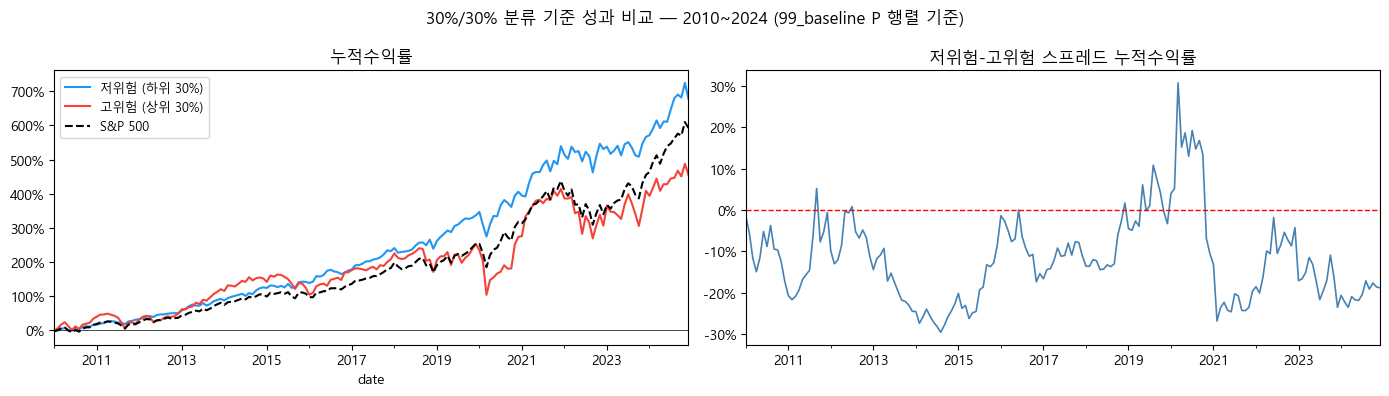

In [47]:
# ── Section 1-2. 30%/30% 분류 기준 성과 (99_baseline P 행렬과 동일) ──
LOW_PCTILE  = 0.30
HIGH_PCTILE = 0.70

def portfolio_30(df, sort_col='vol_252d', ret_col='ret_1m'):
    low_rets, high_rets, dates = [], [], []
    for date, group in df.groupby(level='date'):
        valid = group[[sort_col, ret_col]].dropna()
        if len(valid) < 20:
            continue
        q_low  = valid[sort_col].quantile(LOW_PCTILE)
        q_high = valid[sort_col].quantile(HIGH_PCTILE)
        low_rets.append(valid[valid[sort_col] <= q_low][ret_col].mean())
        high_rets.append(valid[valid[sort_col] >= q_high][ret_col].mean())
        dates.append(date)
    return pd.Series(low_rets, index=pd.DatetimeIndex(dates)), \
           pd.Series(high_rets, index=pd.DatetimeIndex(dates))

low_30, high_30 = portfolio_30(df_bt)
rf_30 = rf_bt.reindex(low_30.index)

def _stats(r, rf, label):
    exc = r - rf
    return {'그룹': label, '연환산 수익률': f'{r.mean()*12:.2%}',
            '연환산 변동성': f'{r.std()*ANN:.2%}',
            'Sharpe': f'{exc.mean()/exc.std()*ANN:.3f}',
            '누적 수익률': f'{(1+r).prod()-1:.2%}'}

print('=== [30%/30% 분류 기준 — 2010~2024] ===')
print(pd.DataFrame([_stats(low_30, rf_30, '저위험 (하위 30%)'),
                    _stats(high_30, rf_30, '고위험 (상위 30%)')]).to_string(index=False))

spread_30     = low_30 - high_30
t30, p30      = stats.ttest_1samp(spread_30.dropna(), 0)
exc_30        = spread_30 - rf_30.reindex(spread_30.index)

print(f'\n[스프레드 (저위험 - 고위험)]')
print(f'  월평균        : {spread_30.mean():.4f}  ({spread_30.mean()*12:.2%} 연환산)')
print(f'  스프레드 변동성: {spread_30.std()*ANN:.2%} (연환산)')
print(f'  Sharpe        : {exc_30.mean()/exc_30.std()*ANN:.3f}')
print(f'  누적 수익률   : {(1+spread_30).prod()-1:.2%}')
print(f'  t-통계량      : {t30:.3f}  p-value: {p30:.4f}  → {"유의 (p<0.05) ✓" if p30 < 0.05 else "비유의 ✗"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('30%/30% 분류 기준 성과 비교 — 2010~2024 (99_baseline P 행렬 기준)', fontsize=12)
ax = axes[0]
(1+low_30).cumprod().sub(1).plot(ax=ax, label='저위험 (하위 30%)', color='#2196F3', linewidth=1.5)
(1+high_30).cumprod().sub(1).plot(ax=ax, label='고위험 (상위 30%)', color='#F44336', linewidth=1.5)
spy_cum_bt.plot(ax=ax, label='S&P 500', color='black', linestyle='--', linewidth=1.5)
ax.set_title('누적수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(fontsize=9)
(1+spread_30).cumprod().sub(1).plot(ax=axes[1], color='steelblue', linewidth=1.2)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('저위험-고위험 스프레드 누적수익률')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

=== [2016~2024] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
베타 분위                                      
Q1     11.04%  12.26%        0.742  151.80%
Q2     12.71%  14.50%        0.742  184.24%
Q3     13.05%  17.54%        0.634  180.51%
Q4     14.51%  20.69%        0.608  202.54%
Q5     15.00%  28.38%        0.461  164.71%

=== [2016~2024] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
변동성 분위                                      
Q1      14.19%  12.42%        0.985  232.65%
Q2      12.49%  14.76%        0.716  177.96%
Q3      13.36%  17.07%        0.670  190.48%
Q4      12.86%  20.05%        0.546  164.40%
Q5      13.39%  27.88%        0.411  131.25%


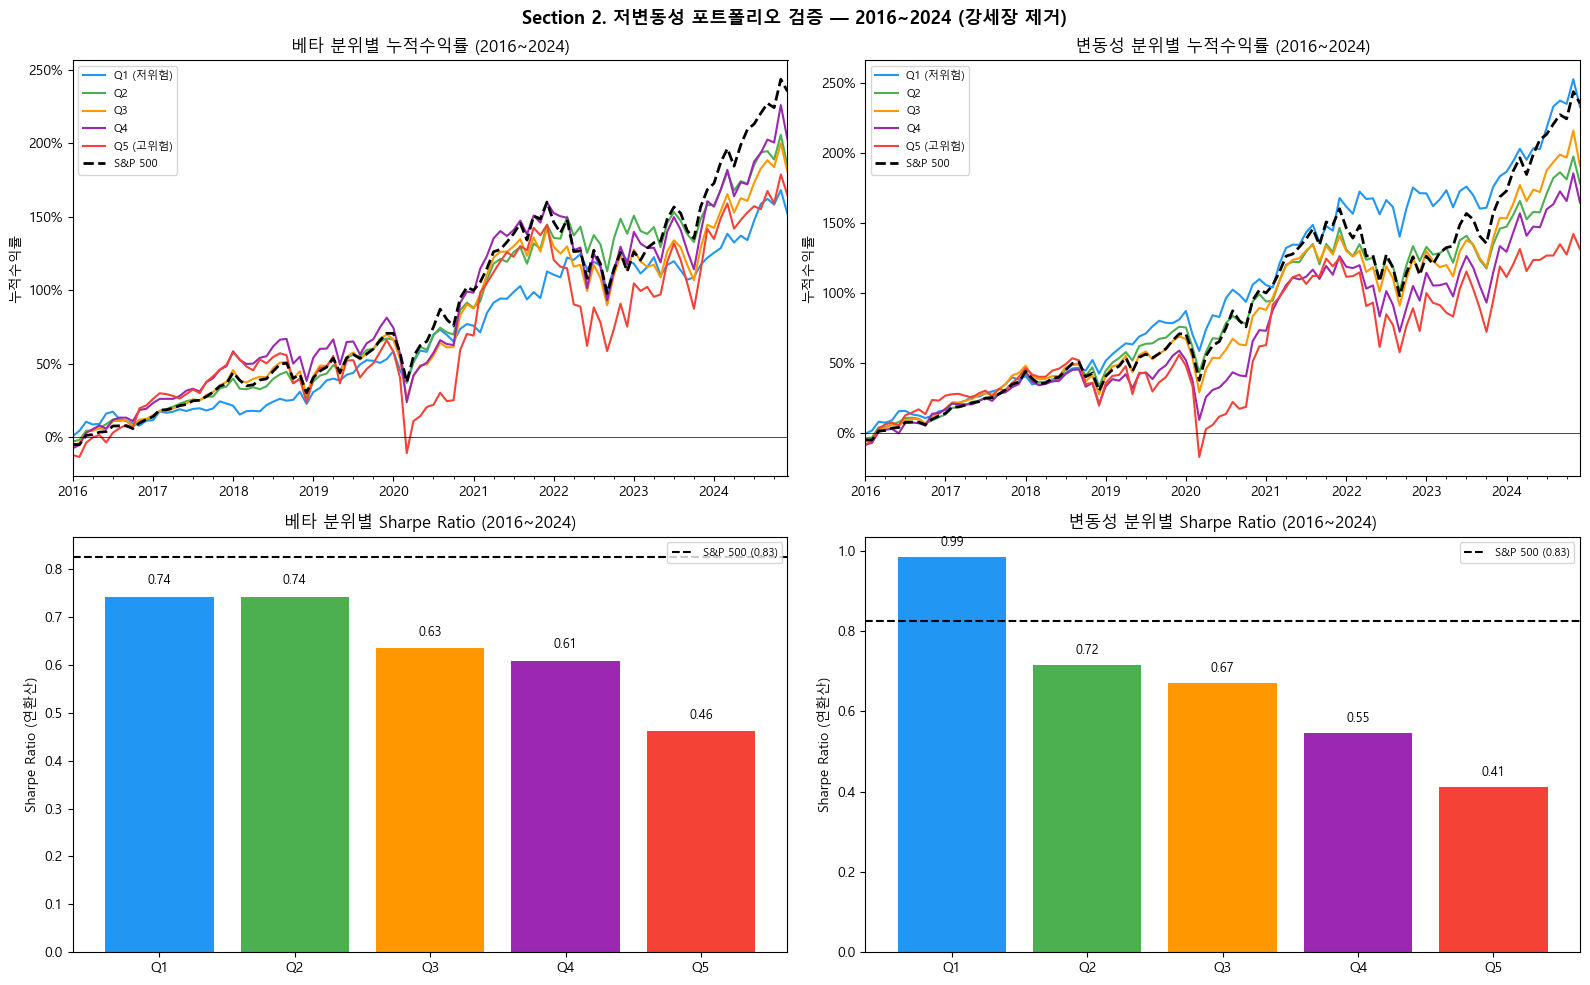

In [48]:
# ── Section 2. 2016~2024 (강세장 제거) ───────────────────────────
# 2010~2015: GFC 이후 QE 주도 강세장 — 고변동성 종목 강한 반등 구간
# 2016 이후 제외하면 저변동 우위가 더 뚜렷하게 나타나는지 확인
START_R = '2016-01-01'
END_R   = '2024-12-31'

df_r         = monthly_df[
    (monthly_df.index.get_level_values('date') >= START_R) &
    (monthly_df.index.get_level_values('date') <= END_R)
]
beta_ports_r = portfolio_sort(df_r, 'beta_252d')
vol_ports_r  = portfolio_sort(df_r, 'vol_252d')
rf_r         = rf_monthly[(rf_monthly.index >= START_R) & (rf_monthly.index <= END_R)]

print('=== [2016~2024] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports_r, rf_r, '베타'))
print('\n=== [2016~2024] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports_r, rf_r, '변동성'))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 2. 저변동성 포트폴리오 검증 — 2016~2024 (강세장 제거)', fontsize=13, fontweight='bold')

rf_b_r  = rf_r.reindex(beta_ports_r.index)
rf_v_r  = rf_r.reindex(vol_ports_r.index)
spy_r   = spy_monthly[(spy_monthly.index >= START_R) & (spy_monthly.index <= END_R)]
spy_cum_r = (1 + spy_r).cumprod() - 1

for ax, ports, title in [
    (axes[0, 0], beta_ports_r, '베타 분위별 누적수익률 (2016~2024)'),
    (axes[0, 1], vol_ports_r,  '변동성 분위별 누적수익률 (2016~2024)'),
]:
    for i, q in enumerate(ports.columns):
        cum = (1 + ports[q].dropna()).cumprod() - 1
        cum.plot(ax=ax, label=labels[i], color=colors[i])
    spy_cum_r.reindex(ports.index).plot(ax=ax, label='S&P 500',
                                         color='black', linestyle='--', linewidth=2)
    ax.set_title(title)
    ax.set_ylabel('누적수익률')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

for ax, ports, rf_a, title in [
    (axes[1, 0], beta_ports_r, rf_b_r, '베타 분위별 Sharpe Ratio (2016~2024)'),
    (axes[1, 1], vol_ports_r,  rf_v_r, '변동성 분위별 Sharpe Ratio (2016~2024)'),
]:
    sr_vals = [(ports[q] - rf_a).mean() / (ports[q] - rf_a).std() * ANN
               for q in ports.columns]
    spy_sr  = (spy_r.reindex(ports.index) - rf_a).mean() / \
              (spy_r.reindex(ports.index) - rf_a).std() * ANN
    bars = ax.bar([f'Q{q}' for q in ports.columns], sr_vals, color=colors)
    ax.axhline(spy_sr, color='black', linestyle='--', linewidth=1.5,
               label=f'S&P 500 ({spy_sr:.2f})')
    ax.set_title(title)
    ax.set_ylabel('Sharpe Ratio (연환산)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort_2016.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# ── Section 3. 2005~2024 (금융위기 포함 전체 기간) ───────────────
print('=== [2005~2024] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports, rf_monthly, '베타'))
print('\n=== [2005~2024] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports, rf_monthly, '변동성'))

=== [2005~2024] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
베타 분위                                      
Q1     10.46%  11.27%        0.788  607.68%
Q2     12.09%  13.74%        0.765  818.66%
Q3     12.76%  17.53%        0.639  829.98%
Q4     14.02%  20.85%        0.598  958.30%
Q5     14.00%  27.53%        0.452  656.88%

=== [2005~2024] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
변동성 분위                                      
Q1      12.17%  11.27%        0.939  893.01%
Q2      11.69%  14.08%        0.719  740.68%
Q3      12.22%  17.17%        0.621  748.06%
Q4      12.34%  20.16%        0.535  677.58%
Q5      14.90%  27.57%        0.484  804.28%


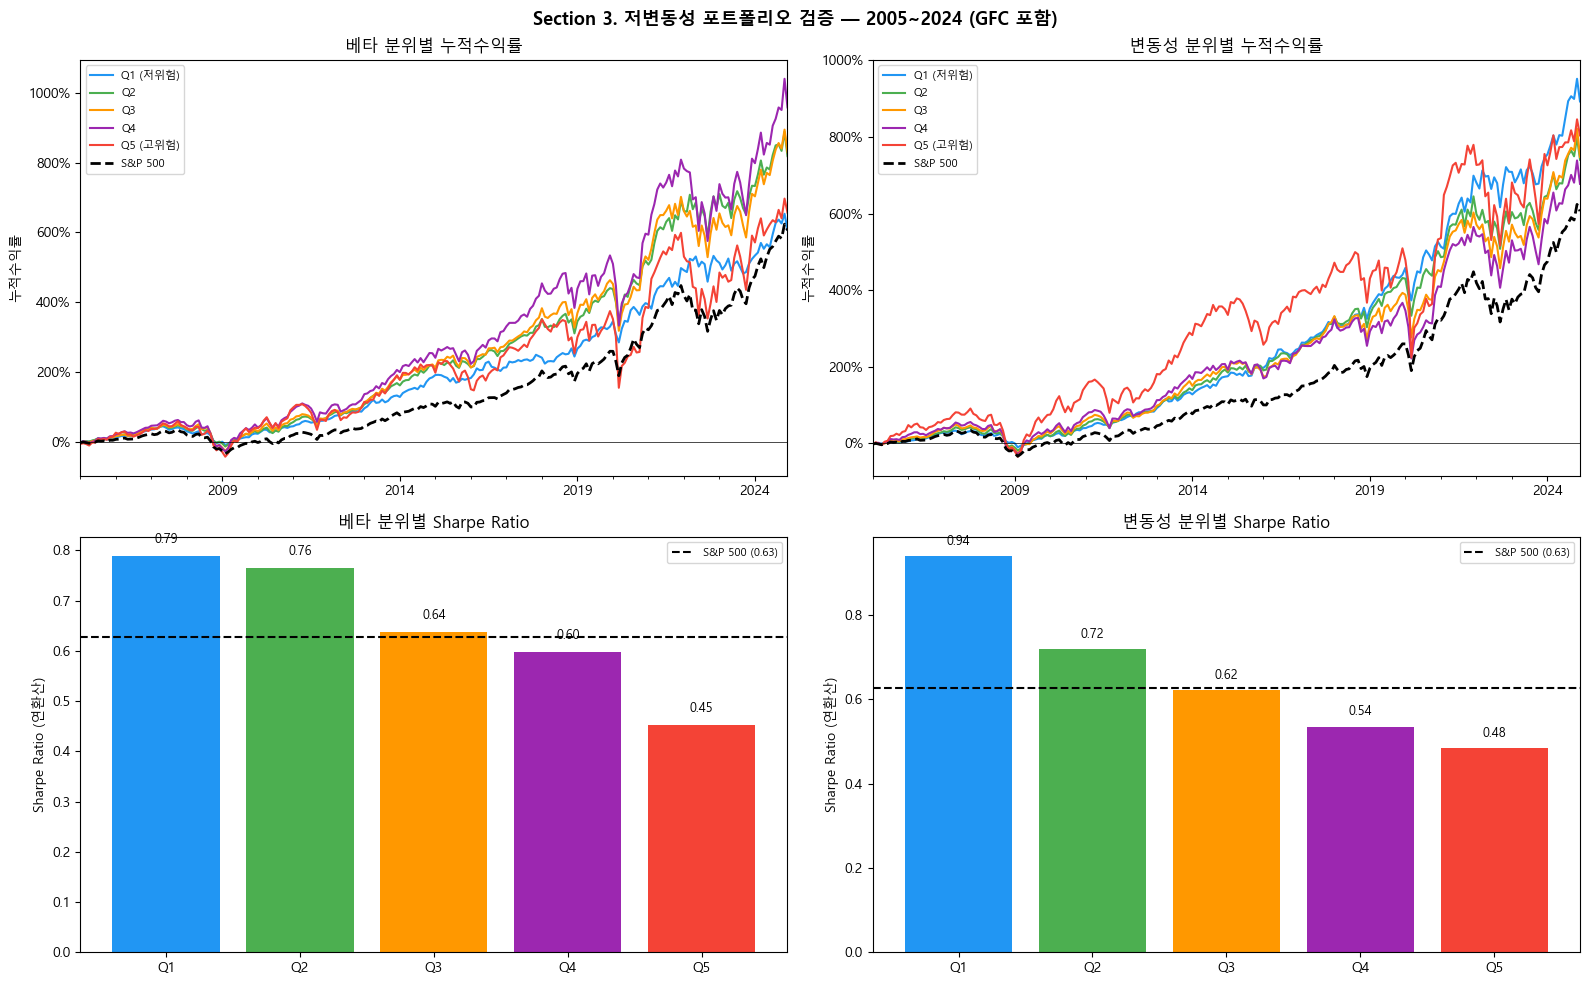

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 3. 저변동성 포트폴리오 검증 — 2005~2024 (GFC 포함)', fontsize=13, fontweight='bold')

spy_cum     = (1 + spy_monthly).cumprod() - 1
rf_a_beta   = rf_monthly.reindex(beta_ports.index)
rf_a_vol    = rf_monthly.reindex(vol_ports.index)

for ax, ports, rf_a, title_cum, title_sr in [
    (axes[0, 0], beta_ports, rf_a_beta, '베타 분위별 누적수익률', '베타 분위별 Sharpe Ratio'),
    (axes[0, 1], vol_ports,  rf_a_vol,  '변동성 분위별 누적수익률', '변동성 분위별 Sharpe Ratio'),
]:
    for i, q in enumerate(ports.columns):
        (1 + ports[q].dropna()).cumprod().sub(1).plot(ax=ax, label=labels[i], color=colors[i])
    spy_cum.reindex(ports.index).plot(ax=ax, label='S&P 500', color='black', linestyle='--', linewidth=2)
    ax.set_title(title_cum)
    ax.set_ylabel('누적수익률')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

for ax, ports, rf_a, title_sr in [
    (axes[1, 0], beta_ports, rf_a_beta, '베타 분위별 Sharpe Ratio'),
    (axes[1, 1], vol_ports,  rf_a_vol,  '변동성 분위별 Sharpe Ratio'),
]:
    sr_vals = [(ports[q] - rf_a).mean() / (ports[q] - rf_a).std() * ANN for q in ports.columns]
    spy_sr  = (spy_monthly.reindex(ports.index) - rf_a).mean() / \
              (spy_monthly.reindex(ports.index) - rf_a).std() * ANN
    bars = ax.bar([f'Q{q}' for q in ports.columns], sr_vals, color=colors)
    ax.axhline(spy_sr, color='black', linestyle='--', linewidth=1.5, label=f'S&P 500 ({spy_sr:.2f})')
    ax.set_title(title_sr)
    ax.set_ylabel('Sharpe Ratio (연환산)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort.png', dpi=150, bbox_inches='tight')
plt.show()

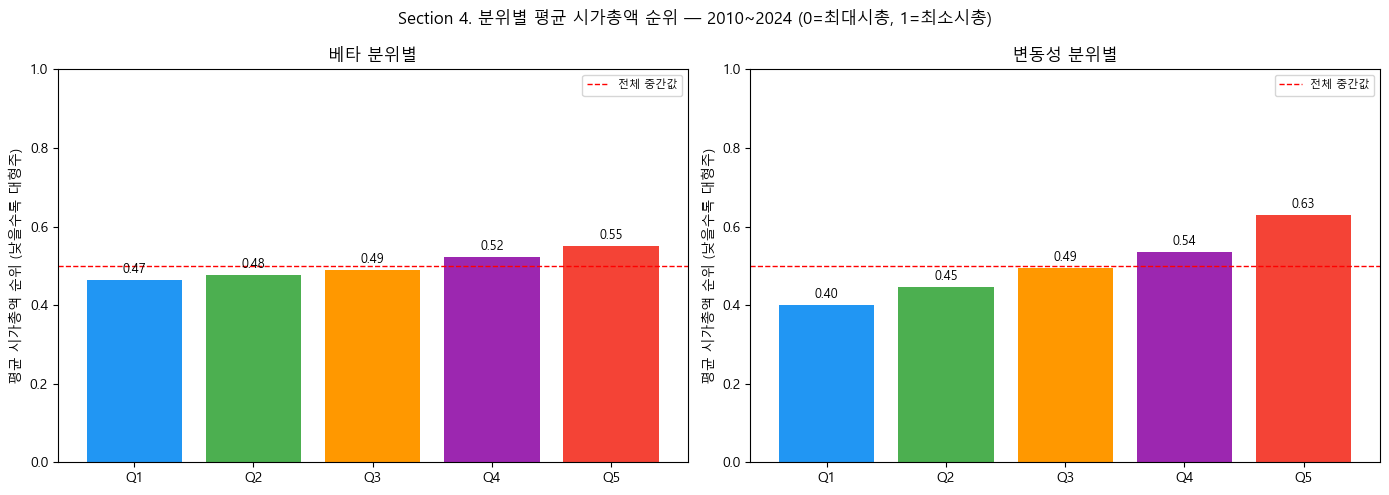

[변동성-시가총액 Spearman 상관관계 검정 — 2010~2024]
  월평균 ρ   : -0.281
  ρ 범위     : -0.425 ~ -0.185
  t-통계량   : -70.909  p-value: 5.99e-133
  해석       : 저변동성 ↔ 대형주 유의한 음의 상관 ✓
  → BL prior(시가총액 가중)와 저변동성 분류가 겹치는 경향 있음


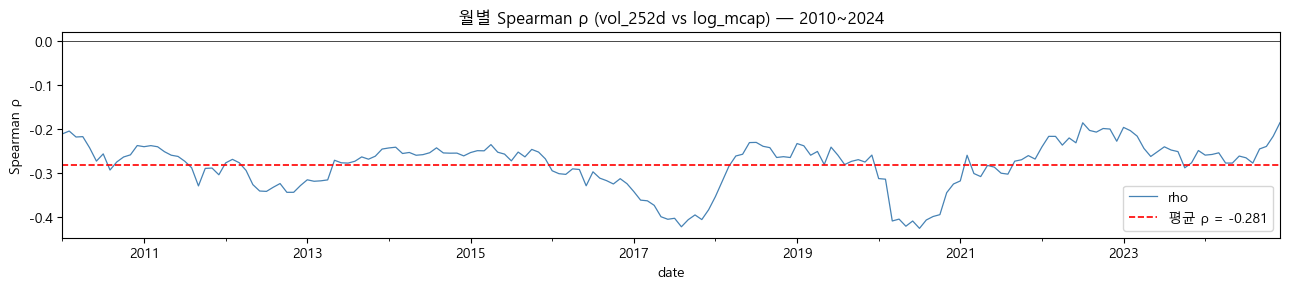

In [51]:
# ── Section 4. 변동성-시가총액 관계 (2010~2024 기준) ────────────
# BL 모델에서 시가총액 가중 prior를 사용하므로
# 저변동성과 대형주가 겹치는지 확인 — 메인 분석 구간(2010~2024) 기준

def quintile_mcap_rank(df, sort_col):
    rows = []
    for date, group in df.groupby(level='date'):
        valid = group[[sort_col, 'log_mcap']].dropna()
        if len(valid) < 25:
            continue
        try:
            valid = valid.copy()
            valid['quintile'] = pd.qcut(valid[sort_col], 5,
                                        labels=[1, 2, 3, 4, 5], duplicates='drop')
            valid['mcap_rank'] = valid['log_mcap'].rank(ascending=False, pct=True)
            for q, grp in valid.groupby('quintile'):
                rows.append({'date': date, 'quintile': int(q),
                             'avg_rank': grp['mcap_rank'].mean()})
        except Exception:
            continue
    return pd.DataFrame(rows)

rank_beta = quintile_mcap_rank(df_bt, 'beta_252d')
rank_vol  = quintile_mcap_rank(df_bt, 'vol_252d')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 4. 분위별 평균 시가총액 순위 — 2010~2024 (0=최대시총, 1=최소시총)', fontsize=12)

for ax, rank_df, title in [
    (axes[0], rank_beta, '베타 분위별'),
    (axes[1], rank_vol,  '변동성 분위별'),
]:
    avg = rank_df.groupby('quintile')['avg_rank'].mean()
    bars = ax.bar([f'Q{q}' for q in avg.index], avg.values, color=colors)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel('평균 시가총액 순위 (낮을수록 대형주)')
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='전체 중간값')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'quintile_mcap_rank.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Spearman 상관관계 검정: 변동성 ↔ 시가총액 (2010~2024) ──────
monthly_corr = []
for date, group in df_bt.groupby(level='date'):
    valid = group[['vol_252d', 'log_mcap']].dropna()
    if len(valid) < 20:
        continue
    rho, _ = stats.spearmanr(valid['vol_252d'], valid['log_mcap'])
    monthly_corr.append({'date': date, 'rho': rho})

corr_df       = pd.DataFrame(monthly_corr).set_index('date')
mean_rho      = corr_df['rho'].mean()
t_stat, p_val = stats.ttest_1samp(corr_df['rho'].dropna(), 0)

print('=' * 55)
print('[변동성-시가총액 Spearman 상관관계 검정 — 2010~2024]')
print('=' * 55)
print(f'  월평균 ρ   : {mean_rho:.3f}')
print(f'  ρ 범위     : {corr_df["rho"].min():.3f} ~ {corr_df["rho"].max():.3f}')
print(f'  t-통계량   : {t_stat:.3f}  p-value: {p_val:.2e}')
print(f'  해석       : 저변동성 ↔ 대형주 {"유의한 음의 상관 ✓" if mean_rho < 0 and p_val < 0.05 else "유의하지 않음"}')
print(f'  → BL prior(시가총액 가중)와 저변동성 분류가 {"겹치는 경향 있음" if mean_rho < -0.2 else "크게 다름"}')

fig, ax = plt.subplots(figsize=(13, 3))
corr_df['rho'].plot(ax=ax, color='steelblue', linewidth=0.9)
ax.axhline(mean_rho, color='red', linestyle='--', linewidth=1.2,
           label=f'평균 ρ = {mean_rho:.3f}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('월별 Spearman ρ (vol_252d vs log_mcap) — 2010~2024')
ax.set_ylabel('Spearman ρ')
ax.legend()
plt.tight_layout()
plt.show()

=== [2005~2009] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio  누적 수익률
베타 분위                                     
Q1      5.08%  11.98%        0.201  24.25%
Q2      6.42%  14.57%        0.257  30.47%
Q3      8.20%  20.69%        0.267  35.00%
Q4     11.15%  24.73%        0.342  50.15%
Q5     11.74%  31.50%        0.288  40.65%

=== [2005~2009] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio  누적 수익률
변동성 분위                                     
Q1       4.59%  11.13%        0.173  21.88%
Q2       5.17%  15.23%        0.164  22.01%
Q3       7.44%  20.31%        0.234  30.55%
Q4       8.95%  23.20%        0.270  36.52%
Q5      16.42%  33.18%        0.414  74.01%

[Pre-sample Q 추정 — 변동성 기준, 2005~2009]
  Q1 월평균 절대수익: 0.0038  |  Q5: 0.0137  |  스프레드: -0.0099
  Q1 월평균 초과수익: 0.0016  |  Q5: 0.0114  |  스프레드: -0.0099
  → 이 값이 99_baseline Q 기준값 (look-ahead bias 없음)


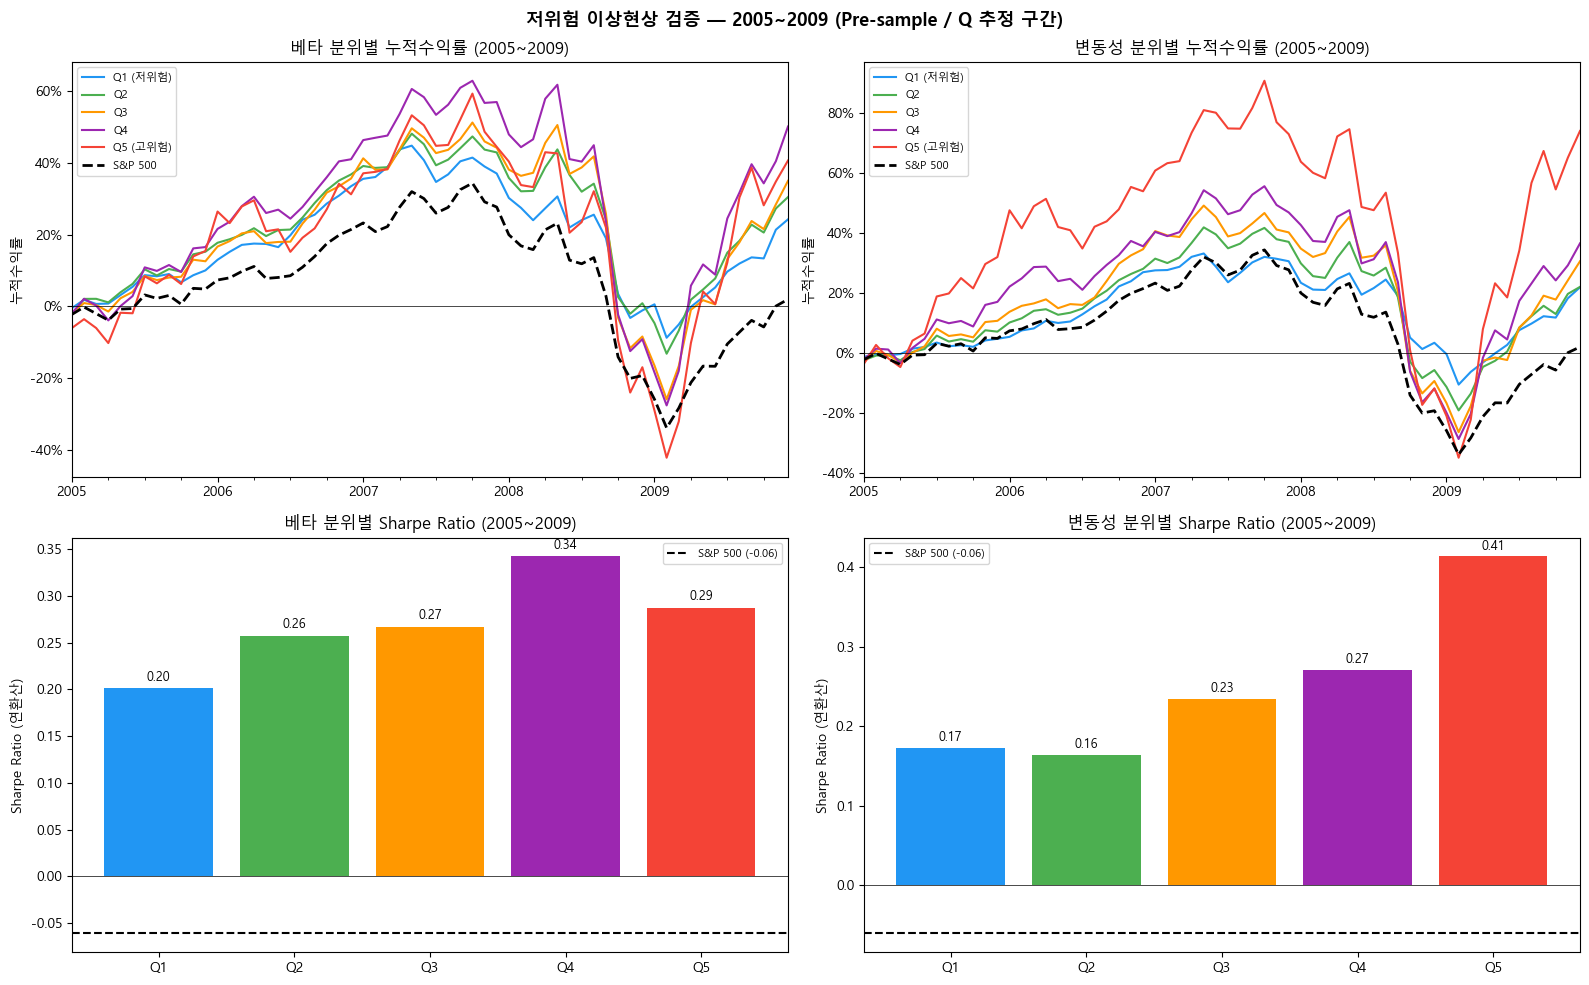

In [52]:
# ── 2005~2009 구간 분석 (pre-sample: Q 추정 근거용) ──────────────
START_PRE = '2005-01-01'
END_PRE   = '2009-12-31'

df_pre         = monthly_df[
    (monthly_df.index.get_level_values('date') >= START_PRE) &
    (monthly_df.index.get_level_values('date') <= END_PRE)
]
beta_ports_pre = portfolio_sort(df_pre, 'beta_252d')
vol_ports_pre  = portfolio_sort(df_pre, 'vol_252d')
rf_pre         = rf_monthly[(rf_monthly.index >= START_PRE) & (rf_monthly.index <= END_PRE)]

print('=== [2005~2009] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports_pre, rf_pre, '베타'))
print('\n=== [2005~2009] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports_pre, rf_pre, '변동성'))

# Q 추정
rf_v_pre  = rf_pre.reindex(vol_ports_pre.index)
q1_raw    = vol_ports_pre[1].mean()
q5_raw    = vol_ports_pre[5].mean()
q1_excess = (vol_ports_pre[1] - rf_v_pre).mean()
q5_excess = (vol_ports_pre[5] - rf_v_pre).mean()
Q_pre     = q1_raw - q5_raw
print(f'\n[Pre-sample Q 추정 — 변동성 기준, 2005~2009]')
print(f'  Q1 월평균 절대수익: {q1_raw:.4f}  |  Q5: {q5_raw:.4f}  |  스프레드: {Q_pre:.4f}')
print(f'  Q1 월평균 초과수익: {q1_excess:.4f}  |  Q5: {q5_excess:.4f}  |  스프레드: {q1_excess - q5_excess:.4f}')
print(f'  → 이 값이 99_baseline Q 기준값 (look-ahead bias 없음)')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('저위험 이상현상 검증 — 2005~2009 (Pre-sample / Q 추정 구간)', fontsize=13, fontweight='bold')

rf_b_pre  = rf_pre.reindex(beta_ports_pre.index)
rf_v_pre2 = rf_pre.reindex(vol_ports_pre.index)
spy_pre   = spy_monthly[(spy_monthly.index >= START_PRE) & (spy_monthly.index <= END_PRE)]
spy_cum_pre = (1 + spy_pre).cumprod() - 1

for ax, ports, title in [
    (axes[0, 0], beta_ports_pre, '베타 분위별 누적수익률 (2005~2009)'),
    (axes[0, 1], vol_ports_pre,  '변동성 분위별 누적수익률 (2005~2009)'),
]:
    for i, q in enumerate(ports.columns):
        cum = (1 + ports[q].dropna()).cumprod() - 1
        cum.plot(ax=ax, label=labels[i], color=colors[i])
    spy_cum_pre.reindex(ports.index).plot(ax=ax, label='S&P 500',
                                           color='black', linestyle='--', linewidth=2)
    ax.set_title(title)
    ax.set_ylabel('누적수익률')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

for ax, ports, rf_a, title in [
    (axes[1, 0], beta_ports_pre, rf_b_pre,  '베타 분위별 Sharpe Ratio (2005~2009)'),
    (axes[1, 1], vol_ports_pre,  rf_v_pre2, '변동성 분위별 Sharpe Ratio (2005~2009)'),
]:
    sr_vals = [(ports[q] - rf_a).mean() / (ports[q] - rf_a).std() * ANN
               for q in ports.columns]
    spy_sr  = (spy_pre.reindex(ports.index) - rf_a).mean() / \
              (spy_pre.reindex(ports.index) - rf_a).std() * ANN
    bars = ax.bar([f'Q{q}' for q in ports.columns], sr_vals, color=colors)
    ax.axhline(spy_sr, color='black', linestyle='--', linewidth=1.5,
               label=f'S&P 500 ({spy_sr:.2f})')
    ax.set_title(title)
    ax.set_ylabel('Sharpe Ratio (연환산)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort_2005pre.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. 결과 요약

아래 셀을 실행하면 주요 검증 결과를 한눈에 정리해줍니다.

In [53]:
print('=' * 55)
print('저위험 이상현상 검증 결과 요약')
print('=' * 55)

rf_b = rf_monthly.reindex(beta_ports.index)
rf_v = rf_monthly.reindex(vol_ports.index)

sr_beta = {q: (beta_ports[q] - rf_b).mean() / (beta_ports[q] - rf_b).std() * ANN
           for q in beta_ports.columns}
sr_vol  = {q: (vol_ports[q]  - rf_v).mean()  / (vol_ports[q]  - rf_v).std()  * ANN
           for q in vol_ports.columns}

print(f'\n[베타 기준]  Q1 SR: {sr_beta[1]:.3f}  →  Q5 SR: {sr_beta[5]:.3f}  '
      f'스프레드: {sr_beta[1]-sr_beta[5]:.3f}  '
      f'→ {"저위험 이상현상 확인 ✓" if sr_beta[1] > sr_beta[5] else "미확인 ✗"}')

print(f'\n[변동성 기준]  Q1 SR: {sr_vol[1]:.3f}  →  Q5 SR: {sr_vol[5]:.3f}  '
      f'스프레드: {sr_vol[1]-sr_vol[5]:.3f}  '
      f'→ {"저위험 이상현상 확인 ✓" if sr_vol[1] > sr_vol[5] else "미확인 ✗"}')

print('\n' + '=' * 55)

저위험 이상현상 검증 결과 요약

[베타 기준]  Q1 SR: 0.788  →  Q5 SR: 0.452  스프레드: 0.336  → 저위험 이상현상 확인 ✓

[변동성 기준]  Q1 SR: 0.939  →  Q5 SR: 0.484  스프레드: 0.455  → 저위험 이상현상 확인 ✓

